<link rel="stylesheet" href="notebooks/styles.css">

<div class="title-wrap">
  <h1 class="title-main" style="font-weight: bold; font-size: 2.65rem; margin-bottom: 0.5rem;">
  Spatial Data Science Approaches to Wildfire Severity Modeling
</h1>
<h2 class="title-sub" style="font-style: italic; font-size: 1.8rem; margin-top: 0rem; margin-bottom: 0.2rem;">
  A GIS‑Driven, Tree‑Based Machine Learning Analysis of California Wildfires
</h2>
</div>

# Module 4: *Variable Selection*
##### Version Number: 4.0
---
### Contents  
> *Water Demand*
> *Water Supply*
> *Water Supply Indexes*
> *Fire Danger Indicators*
> *Social Variables*
> *Elevation*
> *WUI*
> *Ecological*
> *Land Cover*
> *Interactions*
> *Wind Slope*
> *Others*
> *Export File*
---
### Notes
- This module visualizes the distributions of all variables to serve as reference.
---
### Inputs
- `engineered_samples.csv` engineered and cleaned samples data with weather, fire, and grid data.
---
### Outputs 
- 
---
### User Defined Dependencies

In [1]:
import os
import sys

# Allow import of custom modules from the parent directory
sys.path.append(os.path.abspath(os.path.join('..')))

from src.data_utils import *
from src.model_utils import *
from src.plot_utils import *

---
### Third Party Dependencies

In [2]:
# Core data tools
import pandas as pd
import numpy as np
from datetime import datetime
import json

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

# Set consistent plotting style
sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

---

In [3]:
def plot_all(df, target1, target2, target3, title):
    grid_kde(df)

### Load Data

In [ ]:
samples = pd.read_csv('../data/processed/engineered_samples.csv')

---

## Split dataset temporarily for variable analysis

In [5]:
# Columns to drop for feature interaction analysis
text_columns = ['Sample_ID', 'Date', 'grid_id',
       'geometry', 'fire_count', 'total_fire_damage','acres','area_in_cali','maximum_x', 'minimum_y',
       'maximum_y', 'minimum_x','centroid_northing','centroid_easting','Target_Damage','Target_Ignition',
               'Target_Spread','Year','acres_per_day','damage_per_day','acres_burned_so_far','damage_so_far']

coded_columns = ['dominant_province_description','dominant_section_description','Season']

numerical_data = samples.drop(columns=text_columns + coded_columns)
detail_data = samples[text_columns]

target_ignition = samples['Target_Ignition']
target_spread = samples['Target_Spread']
target_damage = samples['Target_Damage']

## Scale numerical columns for easier side by side comparisons

In [6]:
scaler = MinMaxScaler()

# Scale main dataset
X_scaled = scaler.fit_transform(numerical_data)
X = pd.DataFrame(X_scaled, columns=numerical_data.columns, index=numerical_data.index)

X = pd.concat([X,samples[coded_columns]],axis=1)

## DIrect Water Demand Indicators

In [7]:
water_demand = [
    "Actual Evapotranspiration",
    "Solar Radiation",
    "Solar Radiation 7 Day Avg",
    "Daily Minimum Air Temperature",
    "Daily Maximum Air Temperature",
    "Daily Maximum Air Temperature 7 Day Avg",
    "Daily Minimum Air Temperature 7 Day Avg",
    "Vapor Pressure Deficit",
    "Vapor Pressure Deficit 7 Day Avg",
    "Wind Speed",
    "Wind Speed 7 Day Avg",
]

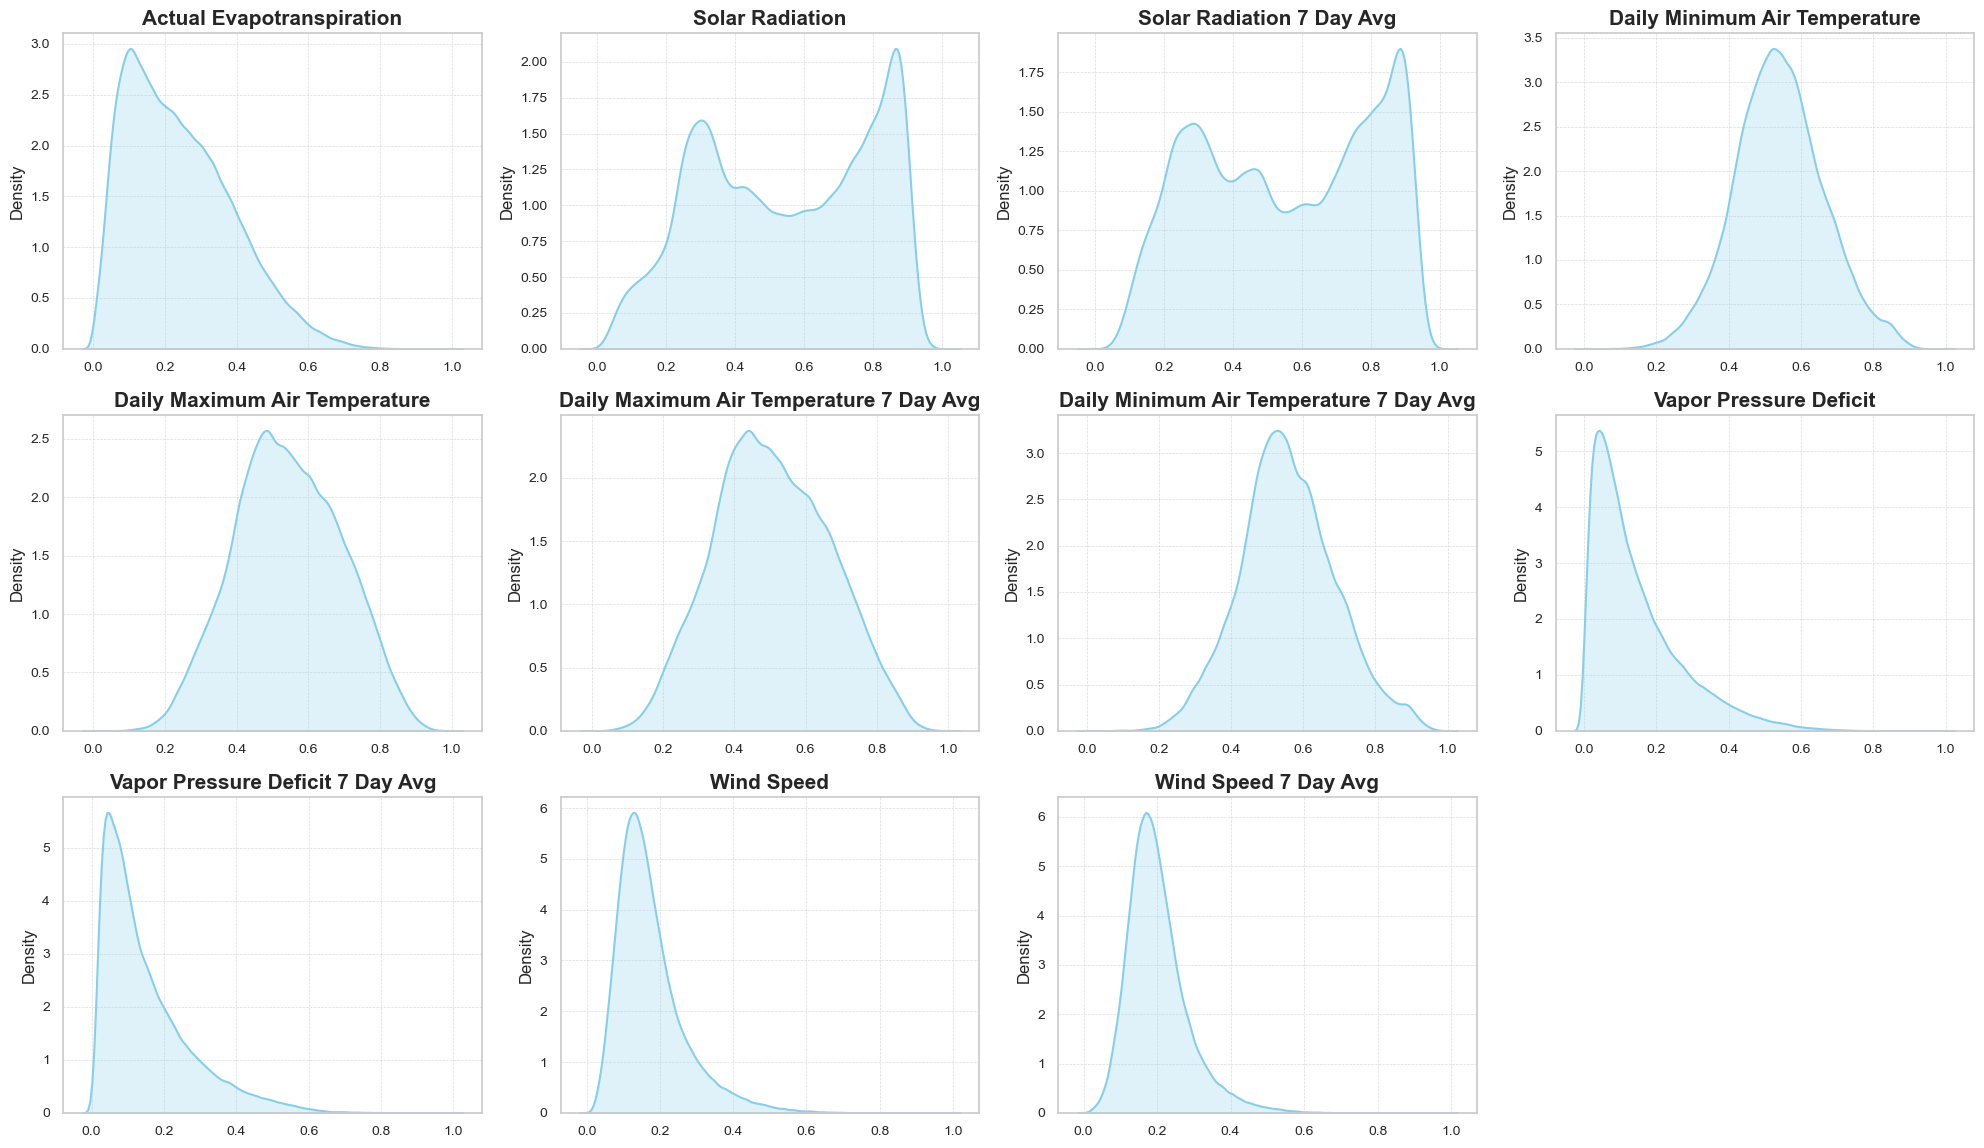

In [8]:
plot_all(X[water_demand], target_ignition, target_spread,target_damage, 'Water Demand')

---

## Water Supply Indicators

In [9]:
water_supply = [
    "Precipitation",
    "Precipitation 7 Day Avg",
    "Maximum Relative Humidity",
    "Minimum Relative Humidity",
    "Maximum Relative Humidity 7 Day Avg",
    "Minimum Relative Humidity 7 Day Avg",
    "Specific Humidity",
    "100-hour Dead Fuel Moisture",
    "1000-hour Dead Fuel Moisture"
]

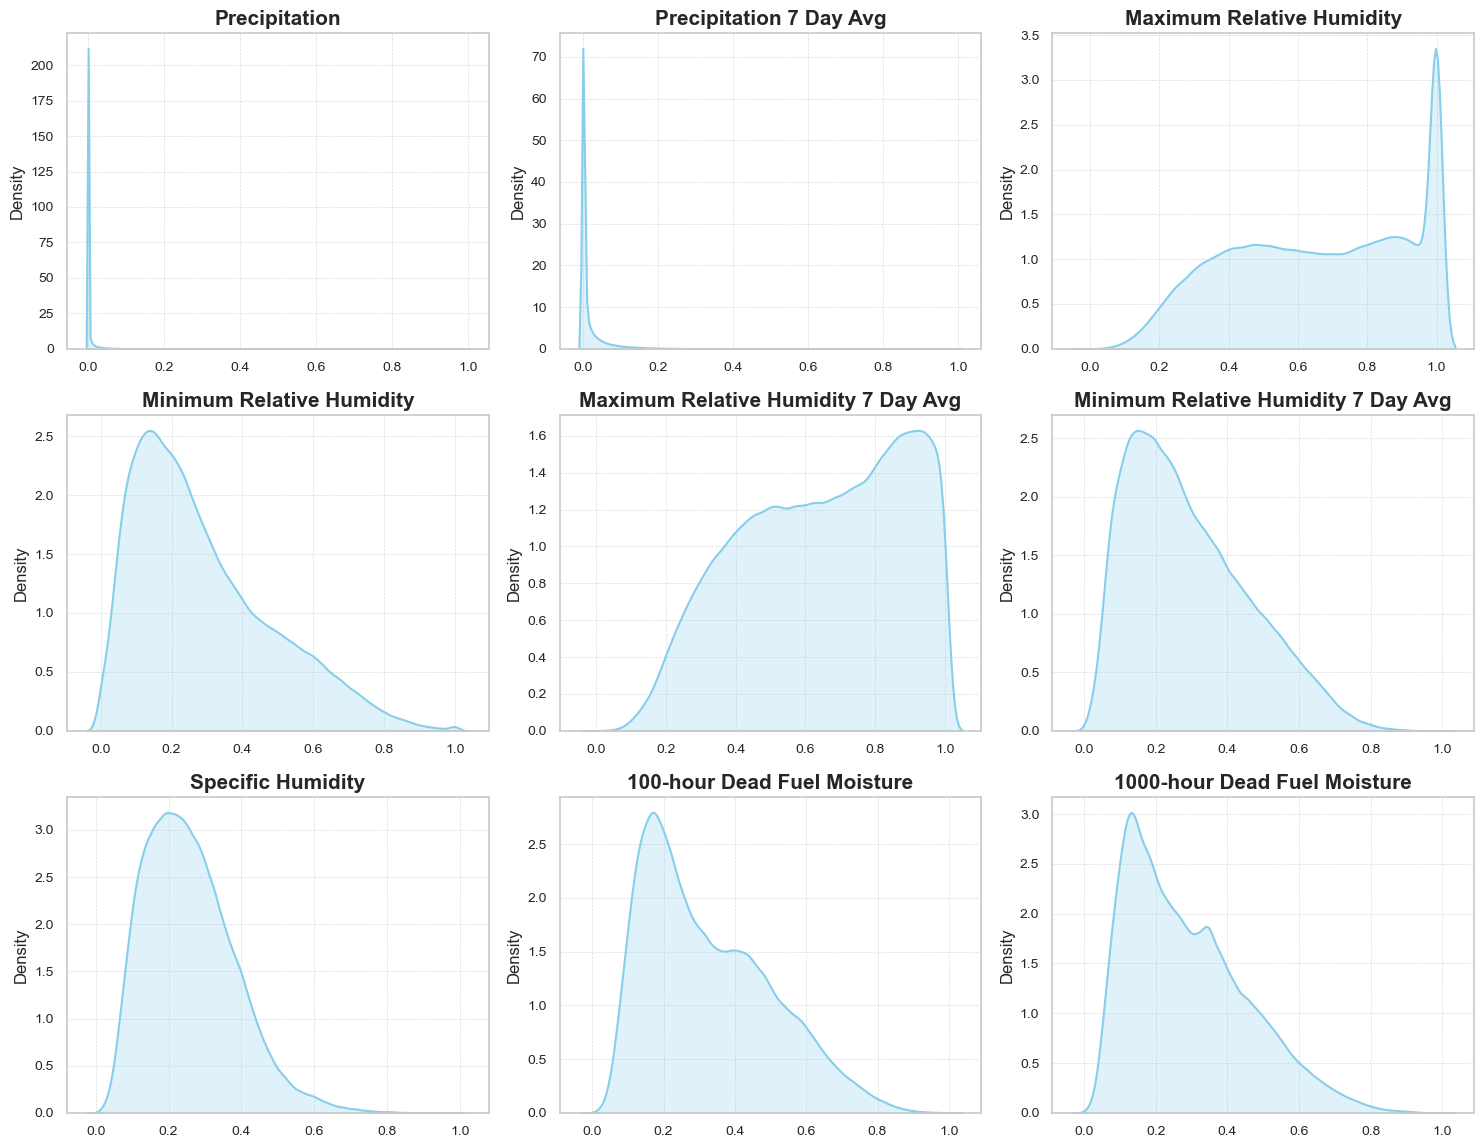

In [10]:
plot_all(X[water_supply], target_ignition, target_spread,target_damage,'Water Supply')

---

## Water Supply Indexes

In [11]:
water_supply_indexes = ["SPI 30-Day",
    "SPI 180-Day",
    "SPEI 30-Day",
    "SPEI 90-Day",
    "SPEI 180-Day",
    "Palmer Drought Severity Index"
]

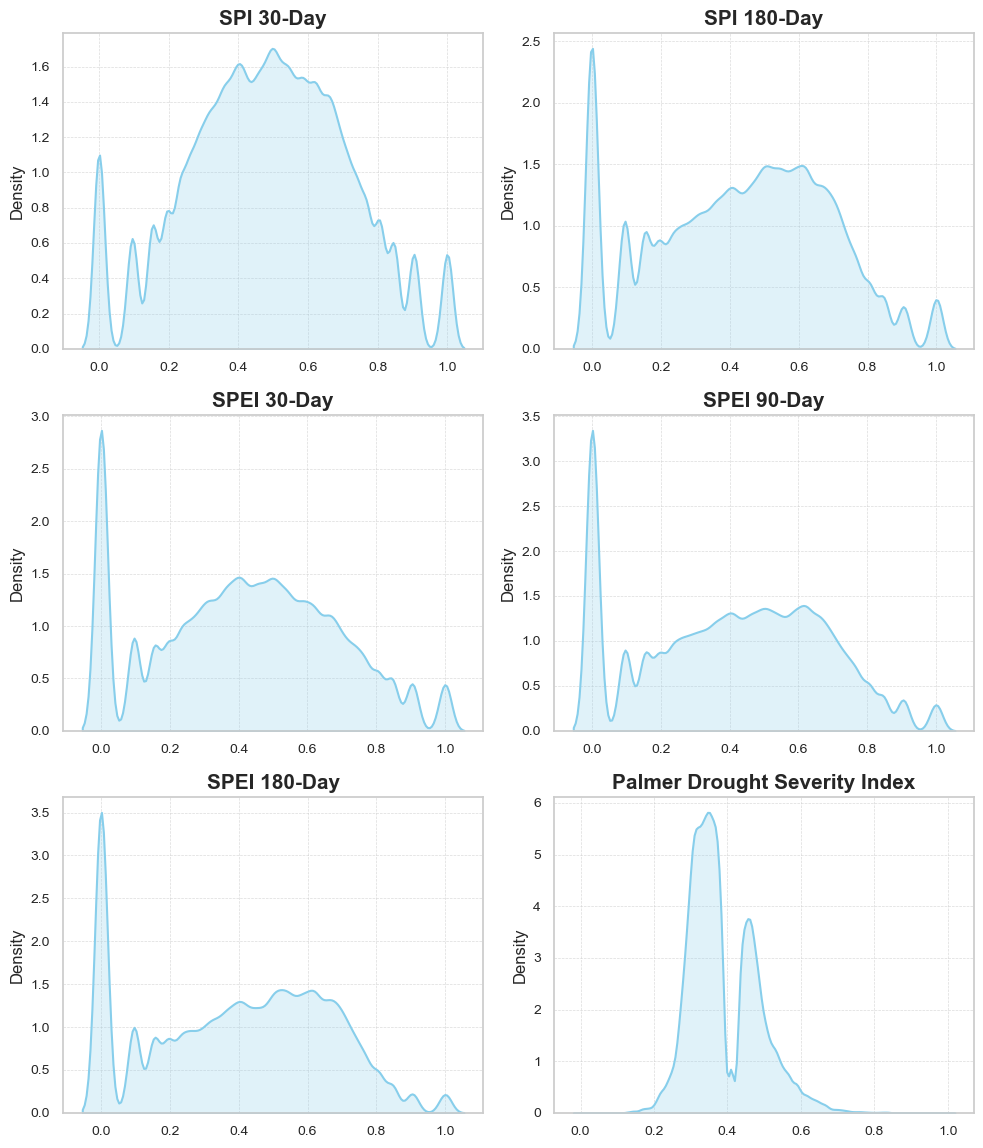

In [12]:
plot_all(X[water_supply_indexes], target_ignition, target_spread,target_damage,'Water Supply Indexes')

## Fire Danger

In [13]:
fire_danger = [
    "Burning Index",
    "Energy Release Component",
    'Santa_Ana_Score']

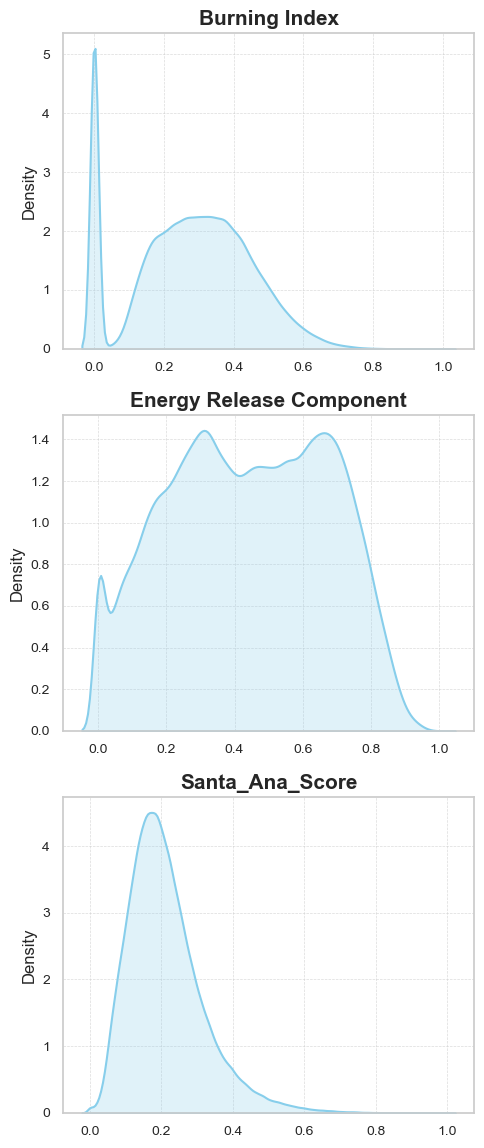

In [14]:
plot_all(X[fire_danger], target_ignition, target_spread,target_damage,'Fire Danger')

## Social Variables

In [15]:
social = ['total_housing', 'total_population',
       'housing_density', 'population_density', 'median_income']

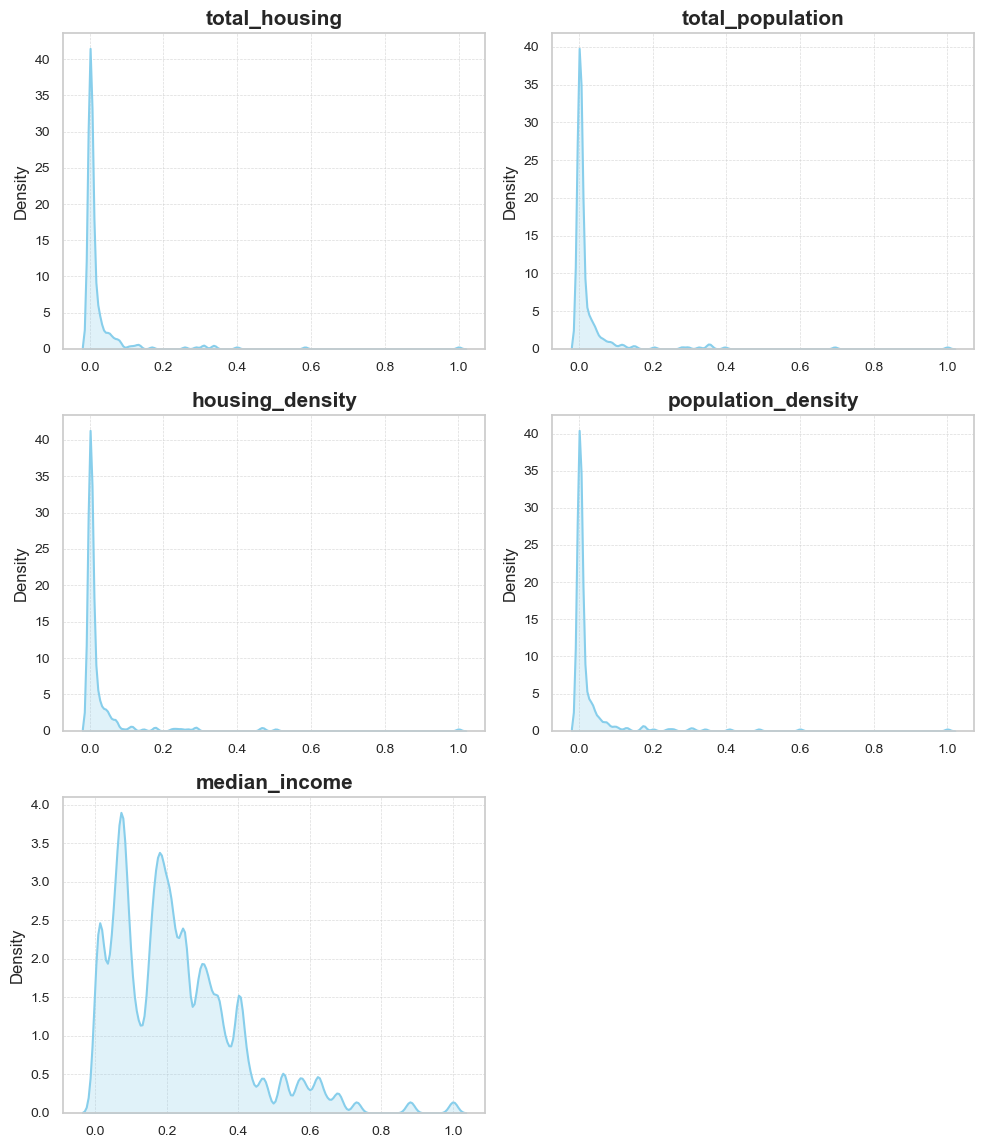

In [16]:
plot_all(X[social], target_ignition, target_spread,target_damage,'Social')

## Elevation

In [17]:
elevation = ['elevation_range', 'elevation_mean',
       'elevation_std', 'slope_max', 'slope_range', 'slope_mean', 'slope_std',
       'northness_mean', 'eastness_mean']

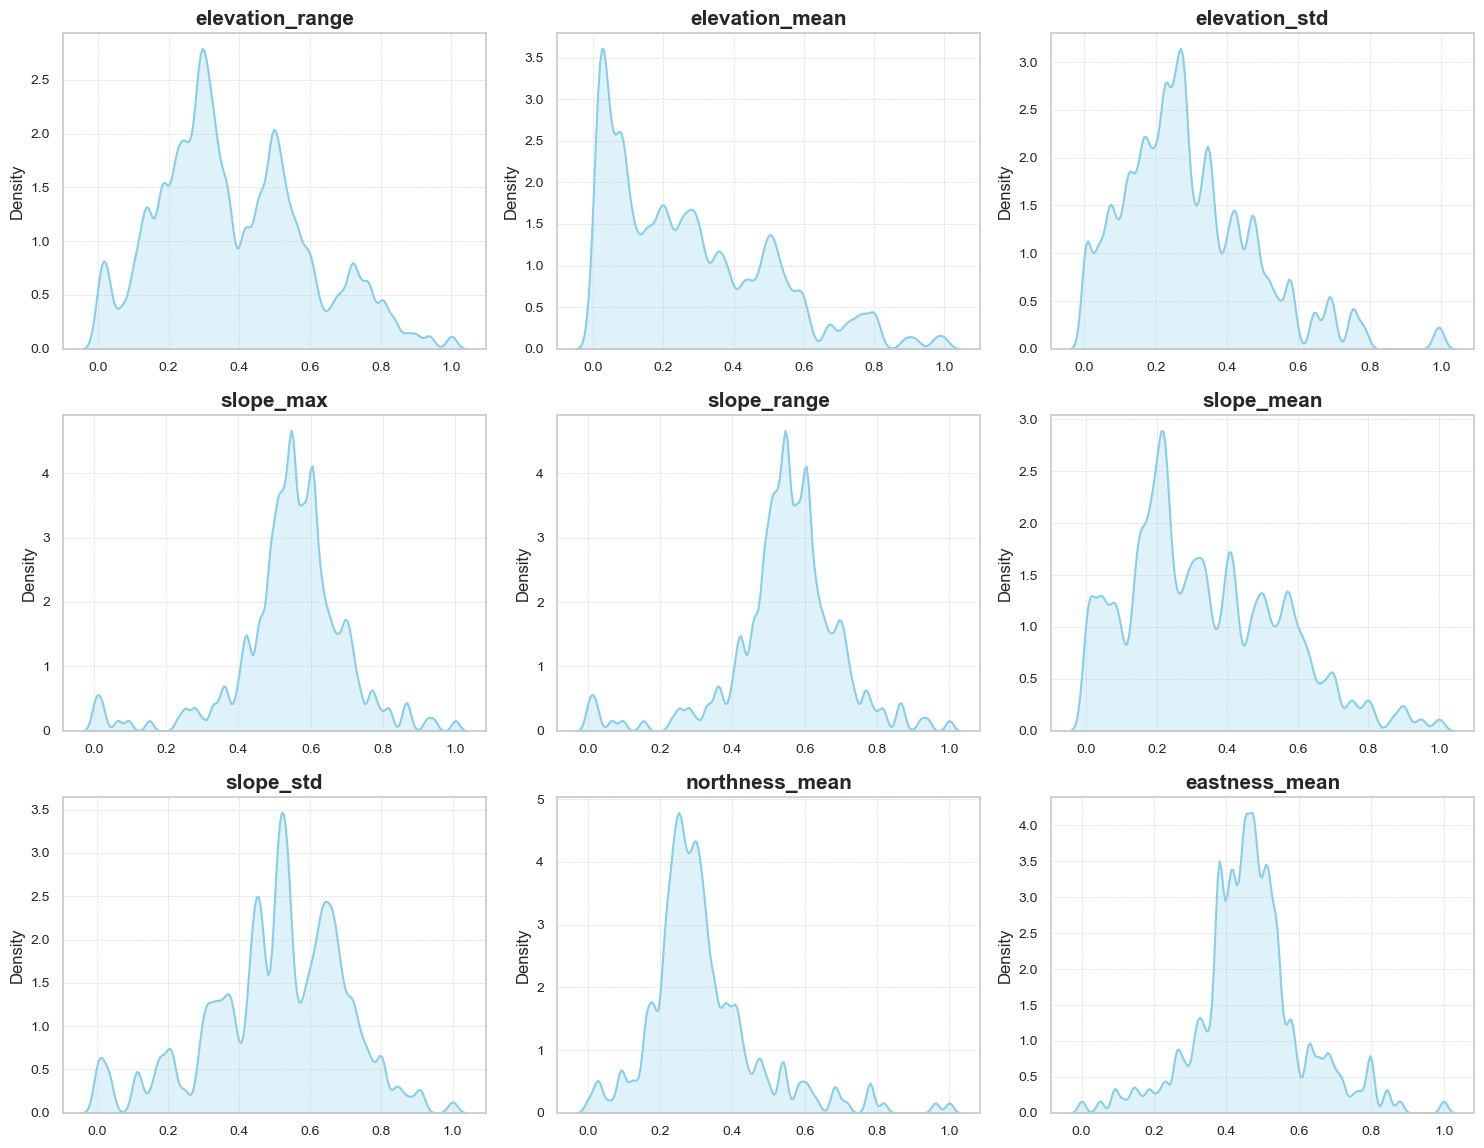

In [18]:
plot_all(X[elevation], target_ignition, target_spread,target_damage,'Elevation')

## WUI

In [19]:
WUI = ['influence_zone', 'interface_zone', 'intermix_zone']

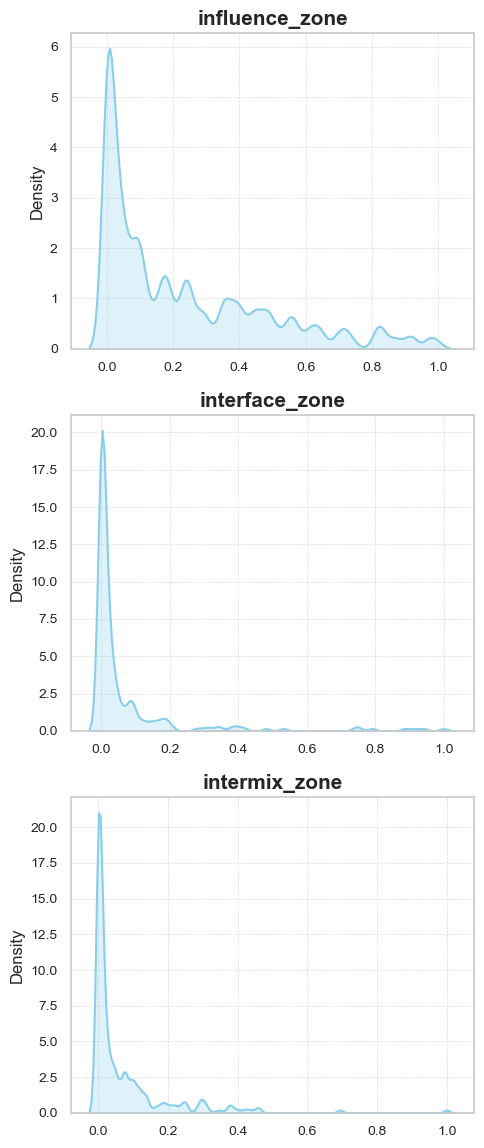

In [20]:
plot_all(X[WUI], target_ignition, target_spread,target_damage,'WUI')

## Ecological

In [21]:
ecoregion = ['dominant_province_percent', 'sum_province_area', 'sum_section_area',
       'dominant_section_percent']

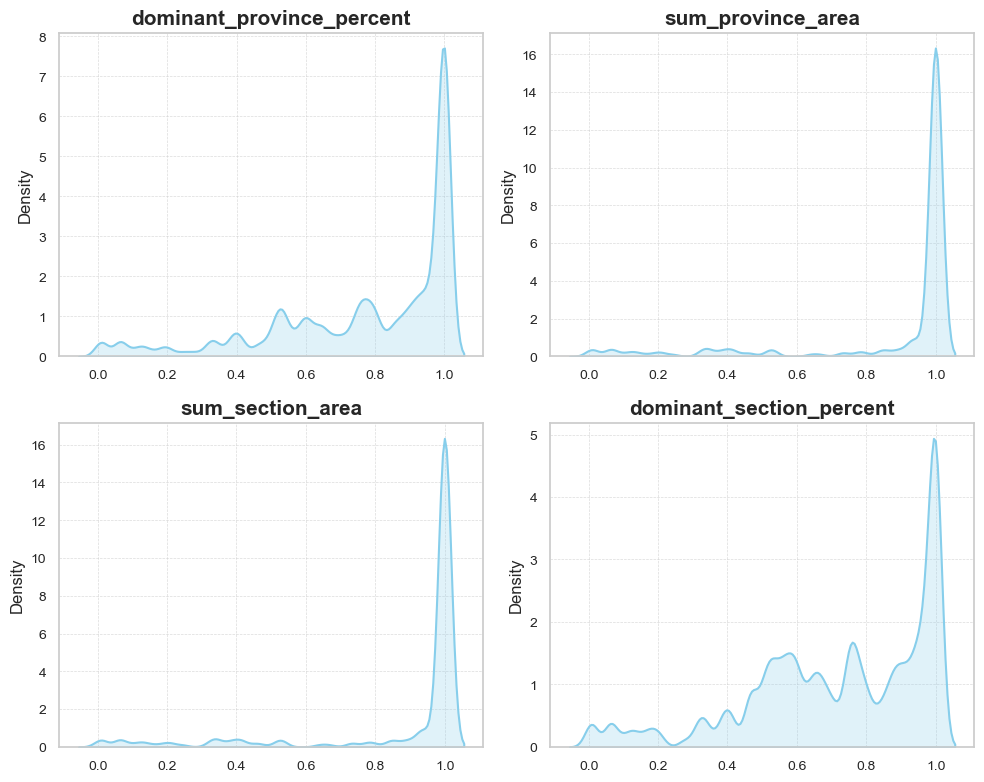

In [22]:
plot_all(X[ecoregion], target_ignition, target_spread,target_damage,'Ecological')

## Land Cover

In [23]:
land_cover = ['forest_percent','developed_percent', 'other_percent', 'shrub_grass_percent',
       'wetlands_percent']

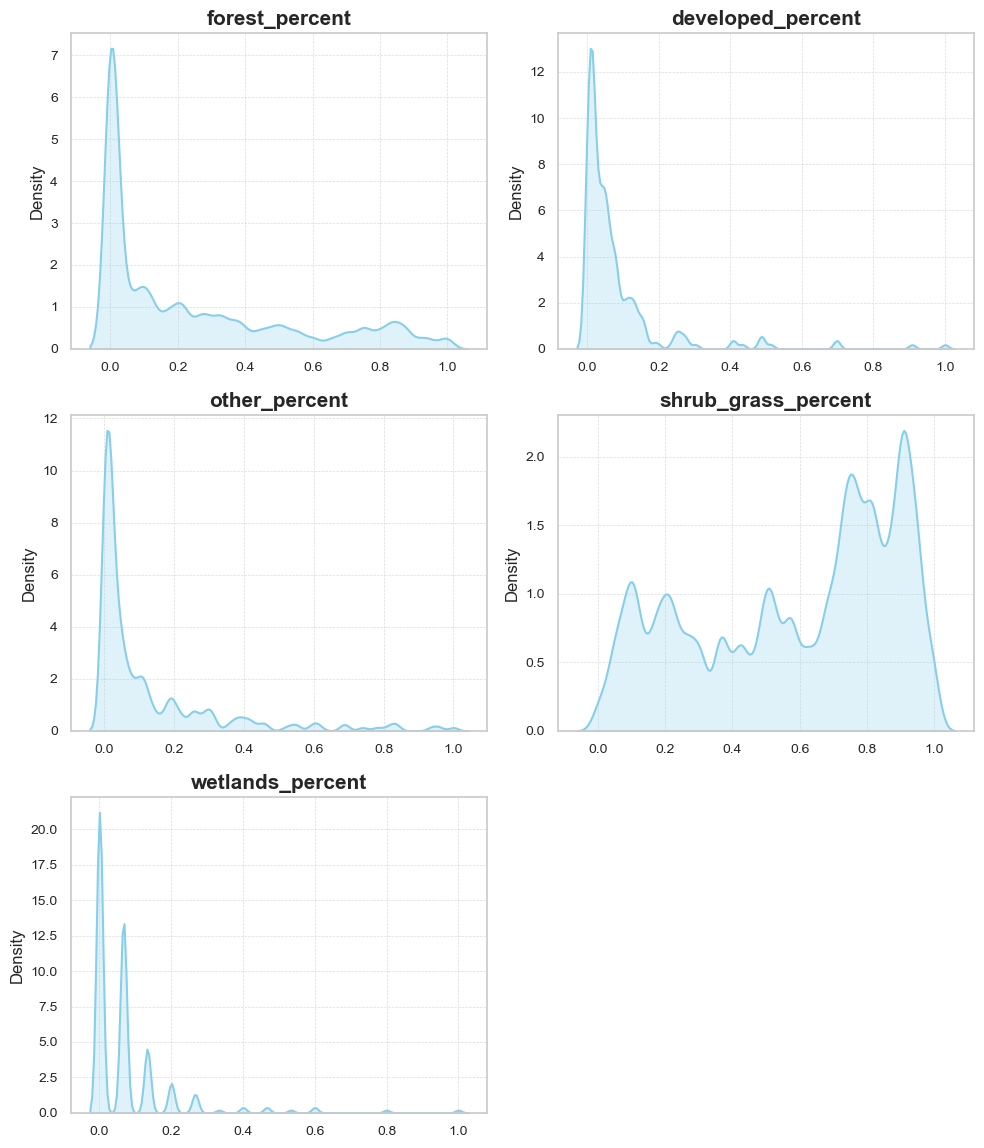

In [24]:
plot_all(X[land_cover], target_ignition, target_spread,target_damage,'Land Cover')

---

In [25]:
interactions = ['Wind Speed_x_100-hour Dead Fuel Moisture',
 'Vapor Pressure Deficit_x_Solar Radiation',
 'Precipitation_x_1000-hour Dead Fuel Moisture',
 'northness_mean_x_Daily Maximum Air Temperature',
 'road_density_x_forest_percent',
 'power_line_density_x_total_housing']

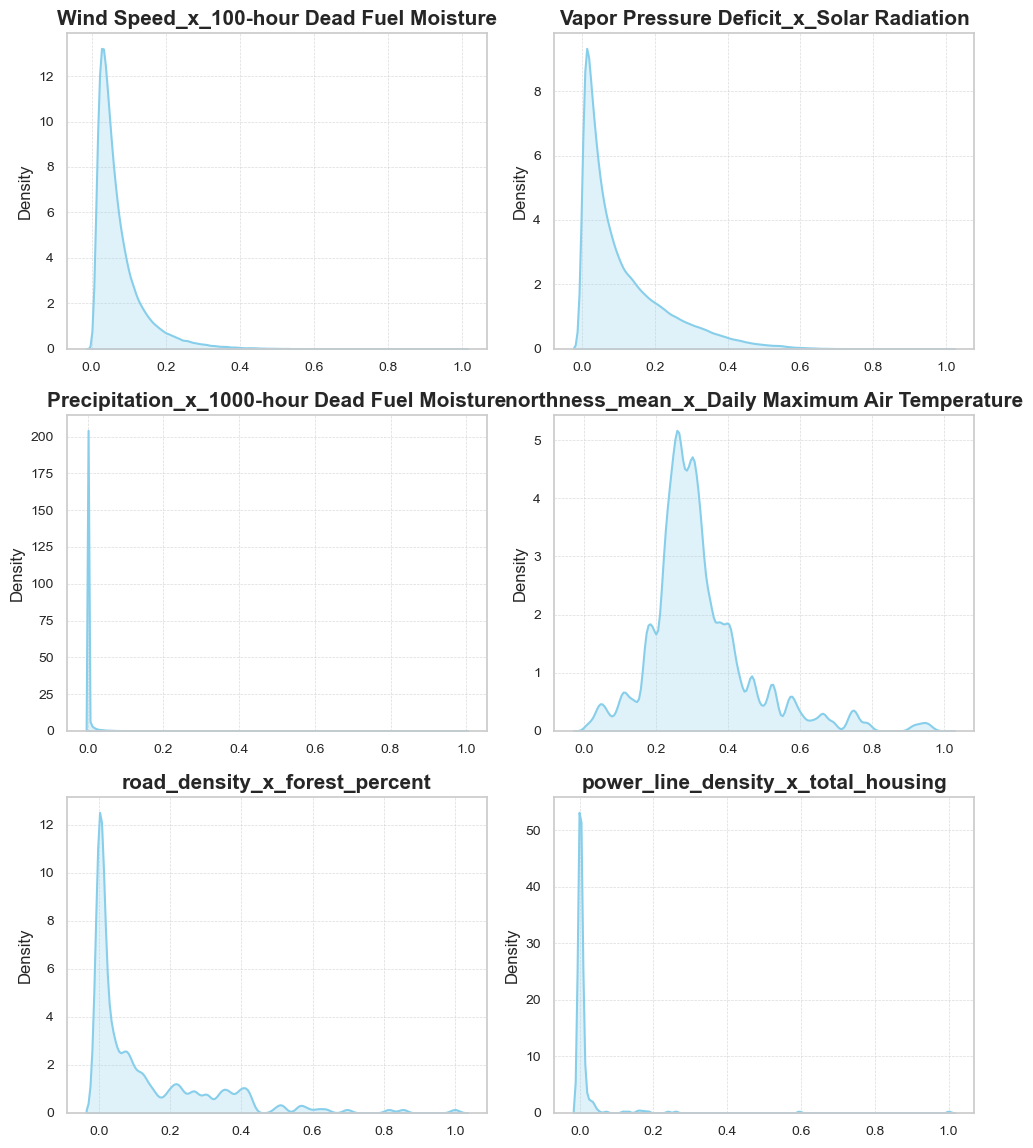

In [26]:
plot_all(X[interactions], target_ignition, target_spread,target_damage,'Interactions')

## Wind Slope Interaction

In [27]:
wind_slope = ['Wind Speed_x_slope_mean',
 'Wind Speed_x_slope_max',
 'Wind Speed_x_northness_mean',
 'Wind Speed_x_eastness_mean',
 'Wind Speed_x_elevation_mean',
 'Wind Speed_x_elevation_range',
 'Wind Speed 7 Day Avg_x_slope_mean',
 'Wind Speed 7 Day Avg_x_slope_max',
 'Wind Speed 7 Day Avg_x_northness_mean',
 'Wind Speed 7 Day Avg_x_eastness_mean',
 'Wind Speed 7 Day Avg_x_elevation_mean',
 'Wind Speed 7 Day Avg_x_elevation_range']

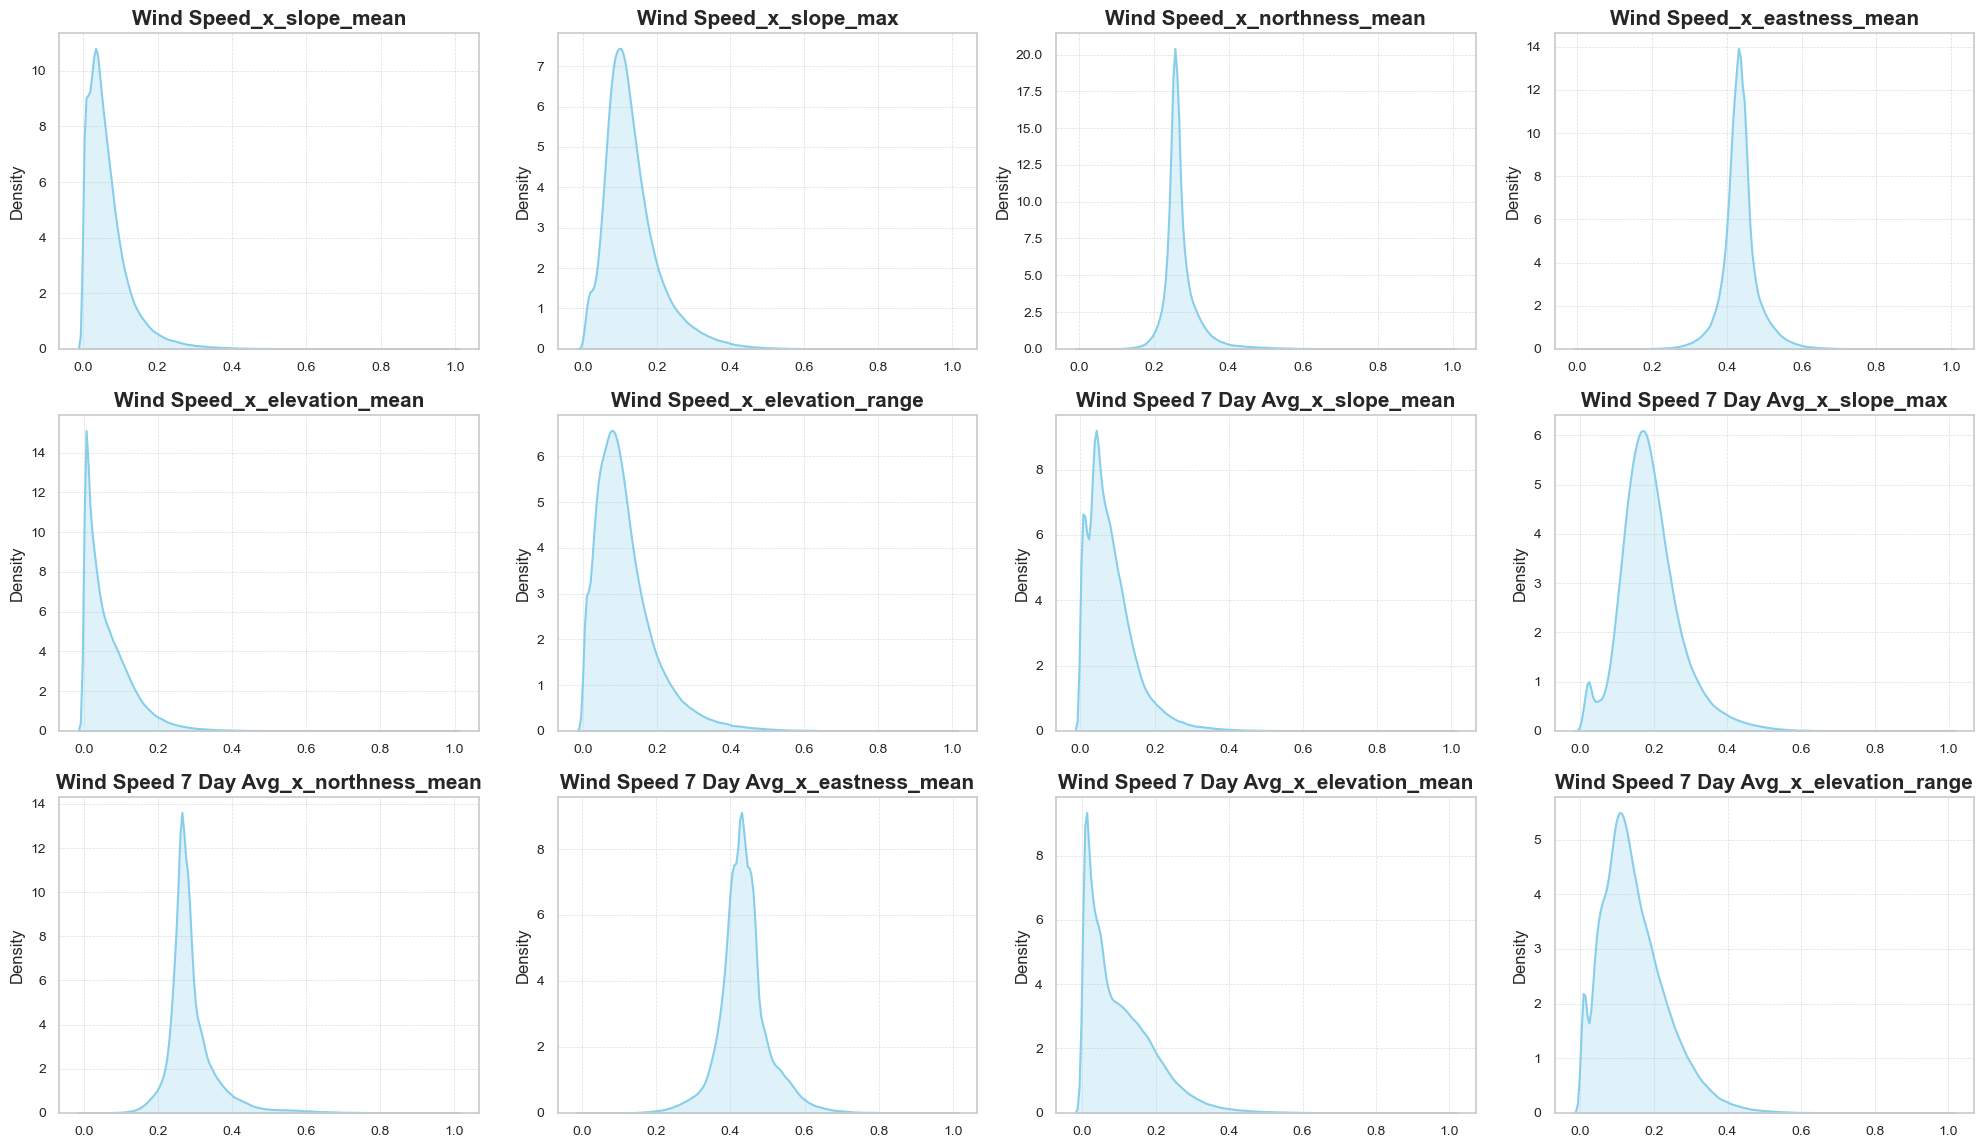

In [28]:
plot_all(X[wind_slope], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

In [29]:
others = [
    "NDVI_mean_difference",
    "NDVI_mean_difference_has_value",
    'reservoir_count',
    'total_reservoir_level',
    'stations_missing_levels'
]

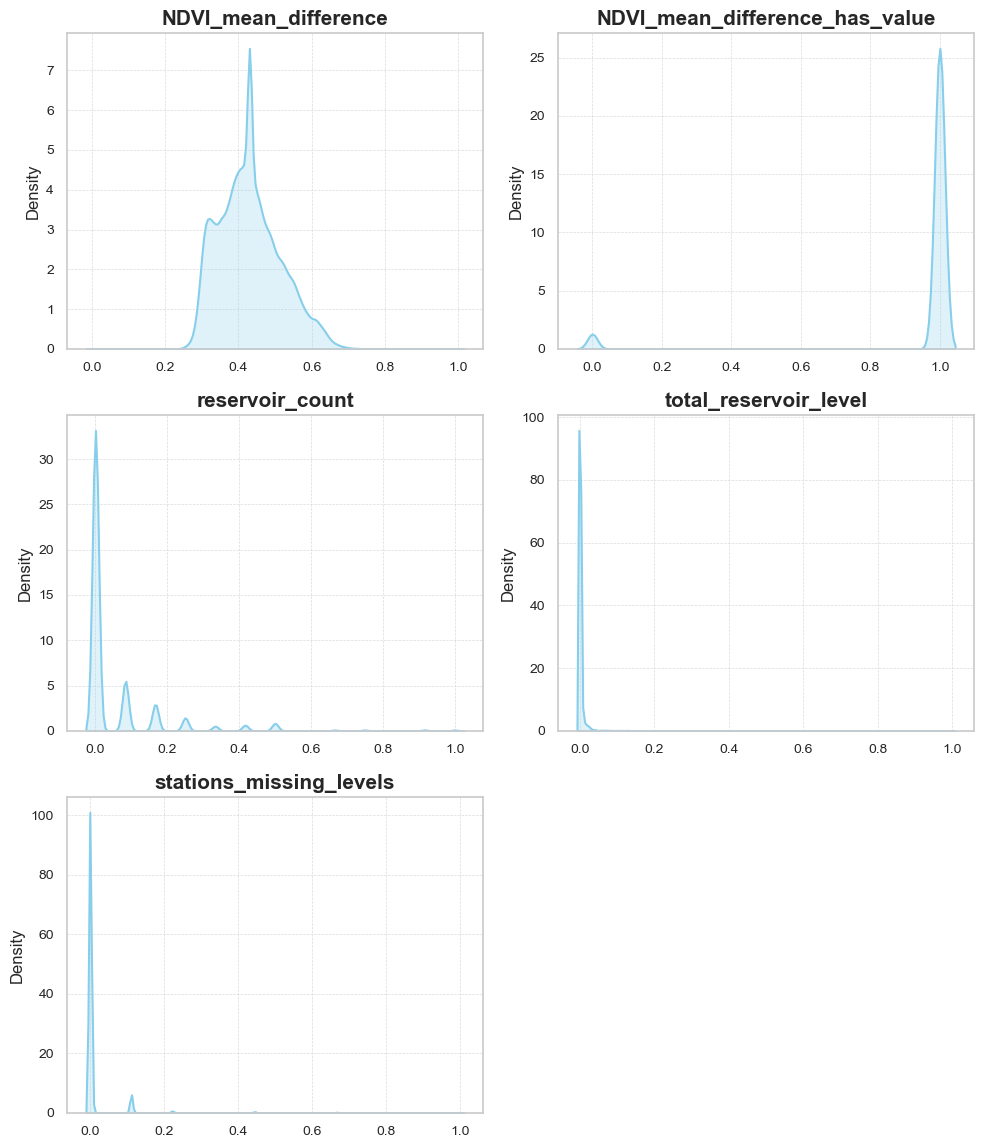

In [30]:
plot_all(X[others], target_ignition, target_spread,target_damage,'Wind Slope Interactions')

In [31]:
coded_ecoregion = [
    # Province
    "dominant_province_description_American Semi-Desert and Desert",
    "dominant_province_description_California Coastal Chaparral Forest and Shrub",
    "dominant_province_description_California Coastal Range Open Woodland-Shrub-Coniferous Forest-Meadow",
    "dominant_province_description_California Coastal Steppe-Mixed Forest-Redwood Forest",
    "dominant_province_description_California Dry Steppe",
    "dominant_province_description_Intermountain Semi-Desert",
    "dominant_province_description_Intermountain Semi-Desert and Desert",
    "dominant_province_description_Sierran Steppe-Mixed Forest-Coniferous Forest-Alpine Meadow",

    # Section
    "dominant_section_description_Central California Coast",
    "dominant_section_description_Central Valley Coast Ranges",
    "dominant_section_description_Colorado Desert",
    "dominant_section_description_Great Valley",
    "dominant_section_description_Klamath Mountains",
    "dominant_section_description_Modoc Plateau",
    "dominant_section_description_Mojave Desert",
    "dominant_section_description_Mono",
    "dominant_section_description_Northern California Coast",
    "dominant_section_description_Northern California Coast Ranges",
    "dominant_section_description_Northern California Interior Coast Ranges",
    "dominant_section_description_Northwestern Basin and Range",
    "dominant_section_description_Sierra Nevada",
    "dominant_section_description_Sierra Nevada Foothills",
    "dominant_section_description_Sonoran Desert",
    "dominant_section_description_Southeastern Great Basin",
    "dominant_section_description_Southern California Coast",
    "dominant_section_description_Southern California Mountains and Valleys",
    "dominant_section_description_Southern Cascades"
]

In [32]:
coded_seasons =[
    'Season_Spring',
    'Season_Summer',
    'Season_Fall',
    'Season_Winter'
]

In [33]:
feature_sets =  {
    "Water Demand": water_demand, 
    "Water Supply": water_supply, 
    "Water Supply Indexes": water_supply_indexes, 
    "Fire Danger": fire_danger,
    "Social": social, 
    "Elevation": elevation, 
    "WUI" : WUI, 
    "Ecoregion": ecoregion, 
    "Land Cover": land_cover, 
    "Interactions": interactions, 
    "Wind Slope": wind_slope,
    "Others": others,
    "Coded Ecoregions": coded_ecoregion,
    "Coded Seasons": coded_seasons
}

In [34]:
variable_selection_output = pd.concat([X, detail_data], axis=1)

## 8. Export File

In [35]:
with open('feature_sets.json', 'w') as f:
    json.dump(feature_sets, f, indent=4)


print("All datasets saved successfully to ../data/processed/")

All datasets saved successfully to ../data/processed/


In [36]:
ignition_xgb_top10 = pd.read_csv('../data/processed/ignition_xgb_top10.csv')
ignition_rf_top10 = pd.read_csv('../data/processed/ignition_rf_top10.csv')
spread_xgb_top10 = pd.read_csv('../data/processed/spread_xgb_top10.csv')
spread_rf_top10 = pd.read_csv('../data/processed/spread_rf_top10.csv')
damage_xgb_top10 = pd.read_csv('../data/processed/damage_xgb_top10.csv')
damage_rf_top10 = pd.read_csv('../data/processed/damage_rf_top10.csv')

In [37]:
spread_xgb_top10 = spread_xgb_top10.drop(spread_xgb_top10.index[4])

In [38]:
ignition_xgb_top5 = list(ignition_xgb_top10.loc[0:5,'0'].values)
ignition_rf_top5 = list(ignition_rf_top10.loc[0:5,'0'].values)
spread_xgb_top5 = list(spread_xgb_top10.loc[0:5,'0'].values)
spread_rf_top5 = list(spread_rf_top10.loc[0:5,'0'].values)
damage_xgb_top5 = list(damage_xgb_top10.loc[0:5,'0'].values)
damage_rf_top5 = list(damage_rf_top10.loc[0:5,'0'].values)

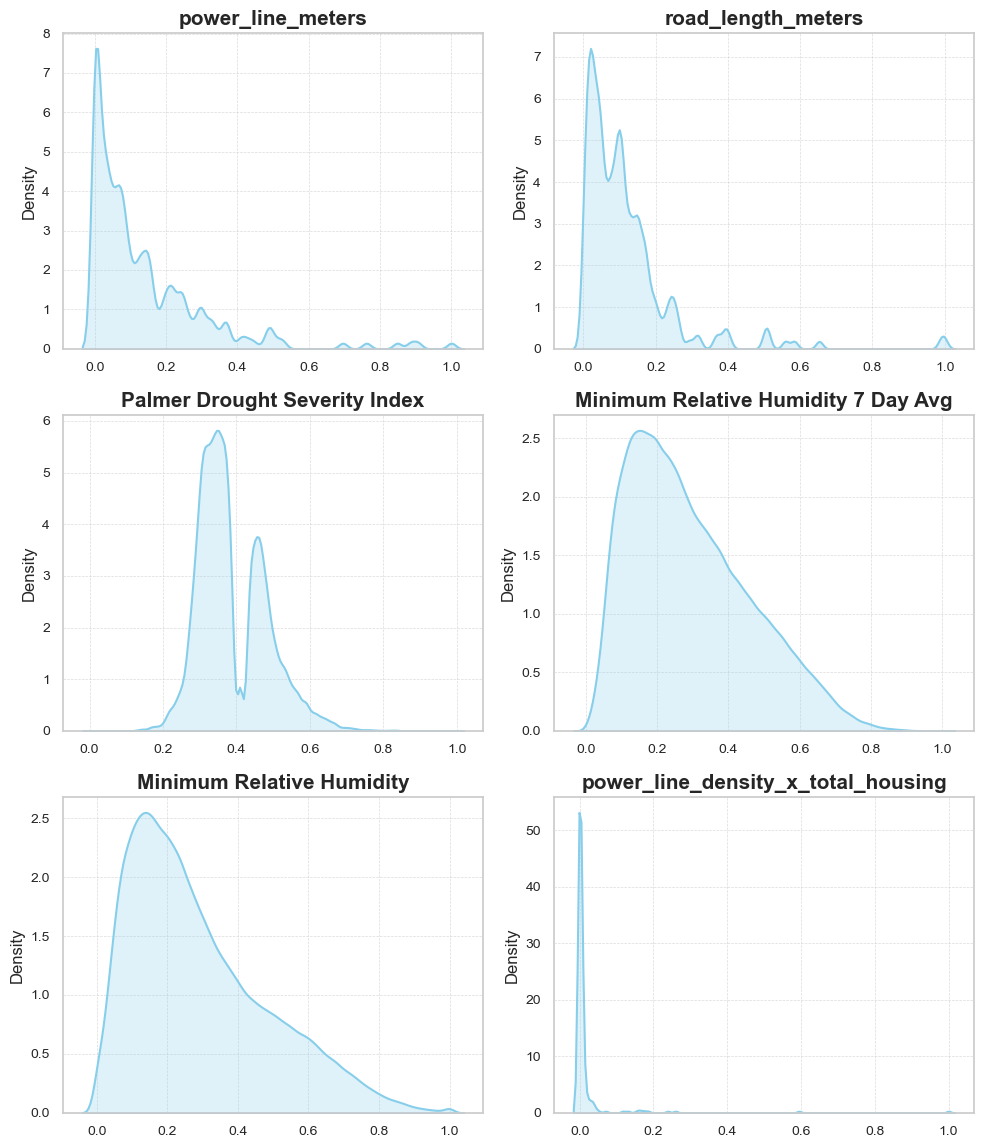

'../plots/features/KDE_{df.columns[0]}.png'

In [41]:
grid_kde(X[ignition_xgb_top5])

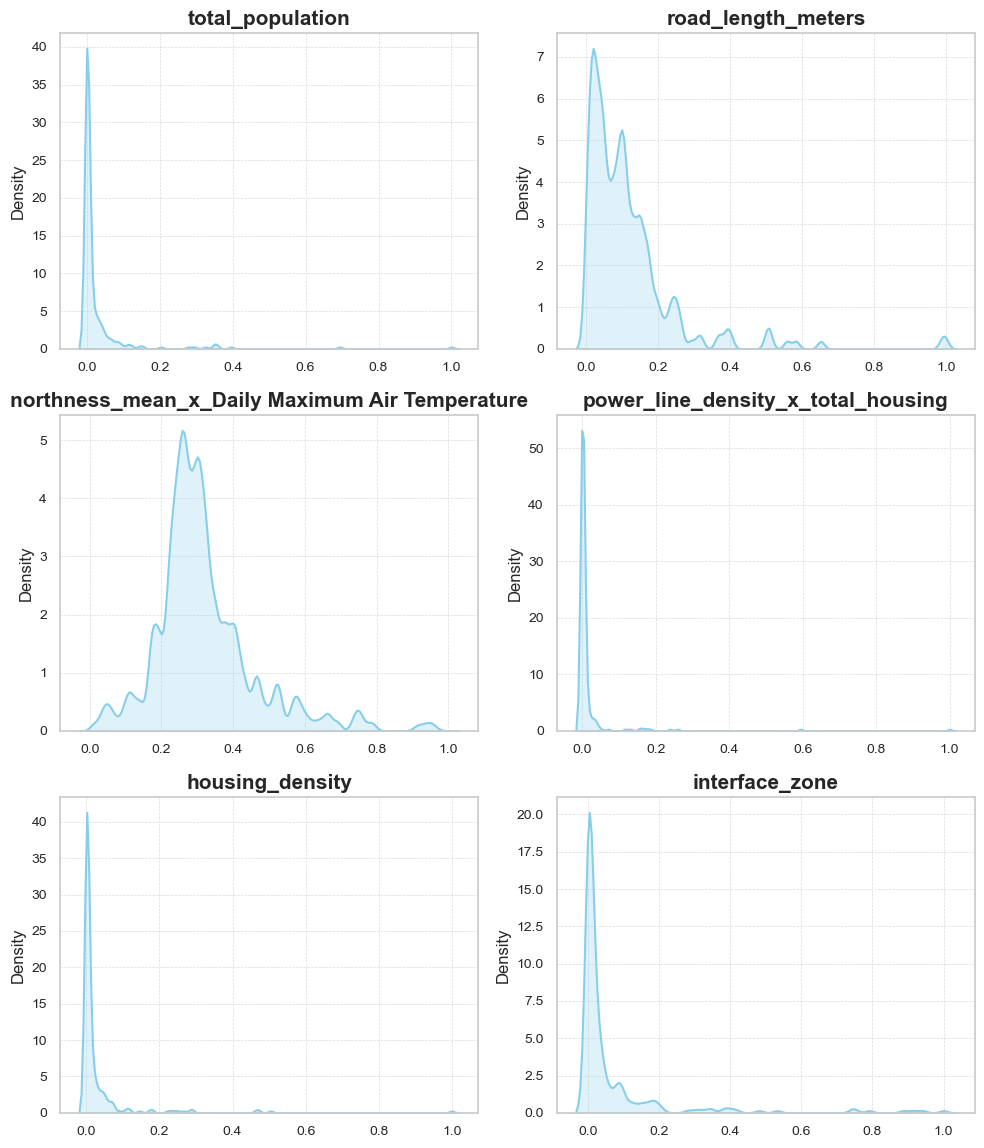

'../plots/features/KDE_{df.columns[0]}.png'

In [42]:
grid_kde(X[ignition_rf_top5])

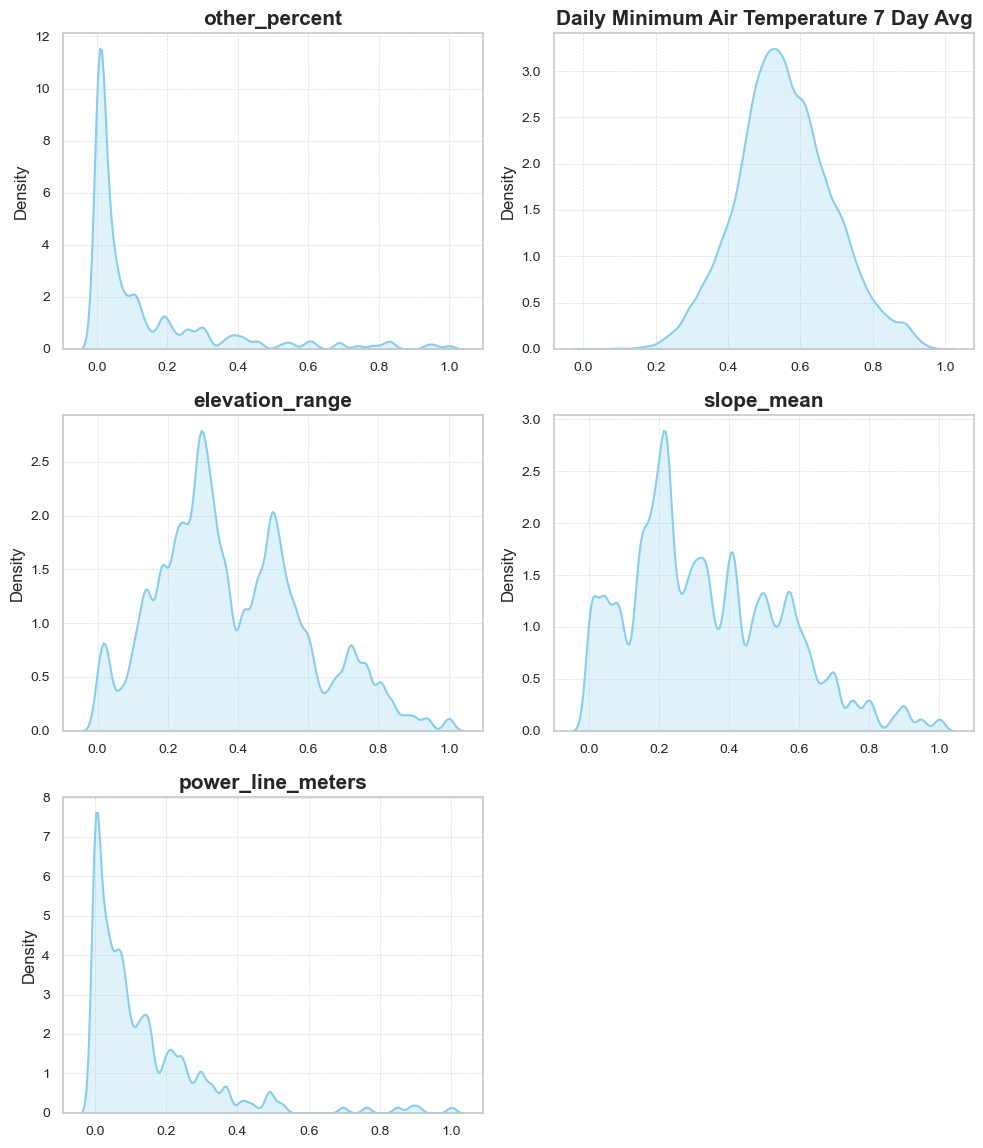

'../plots/features/KDE_{df.columns[0]}.png'

In [47]:
grid_kde(X[spread_xgb_top5])

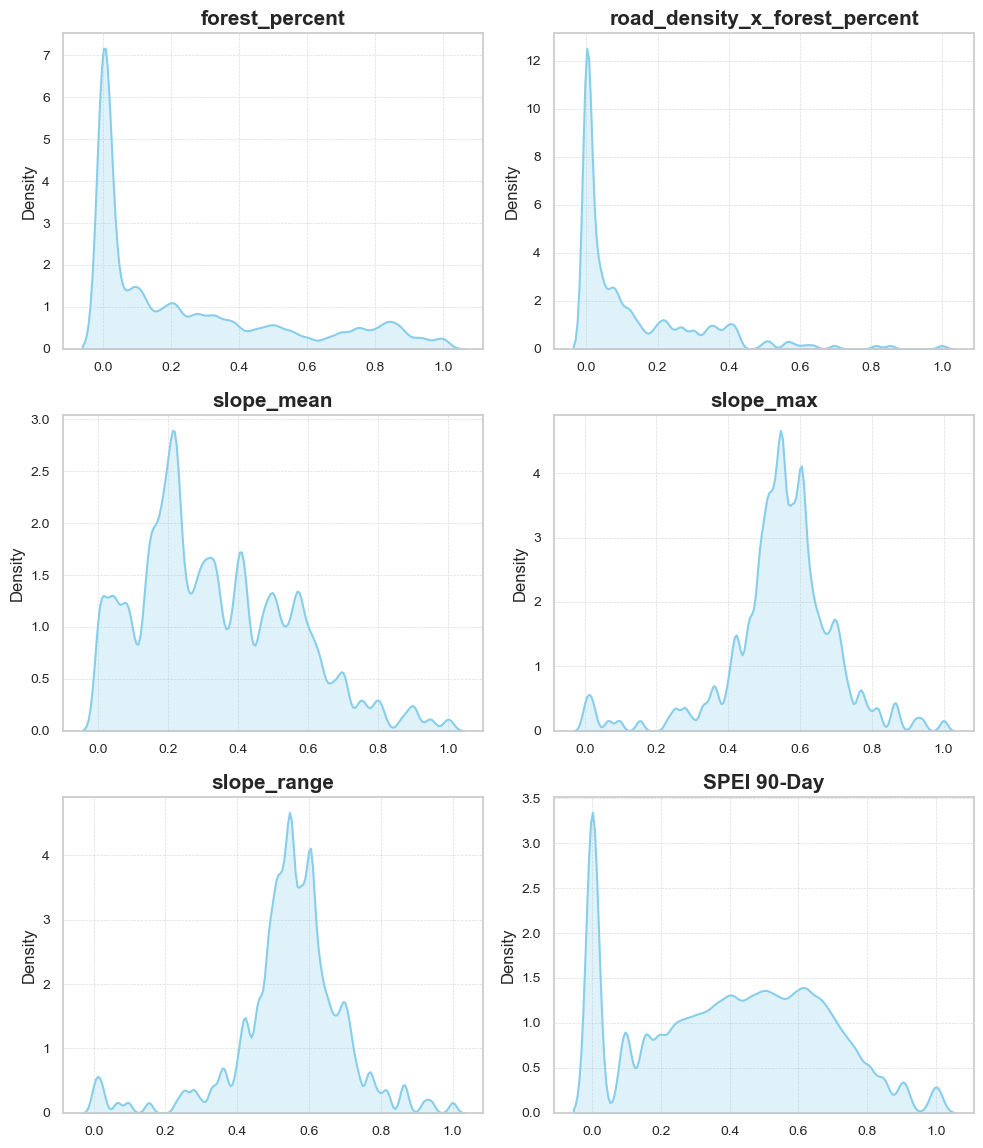

'../plots/features/KDE_{df.columns[0]}.png'

In [48]:
grid_kde(X[spread_rf_top5])

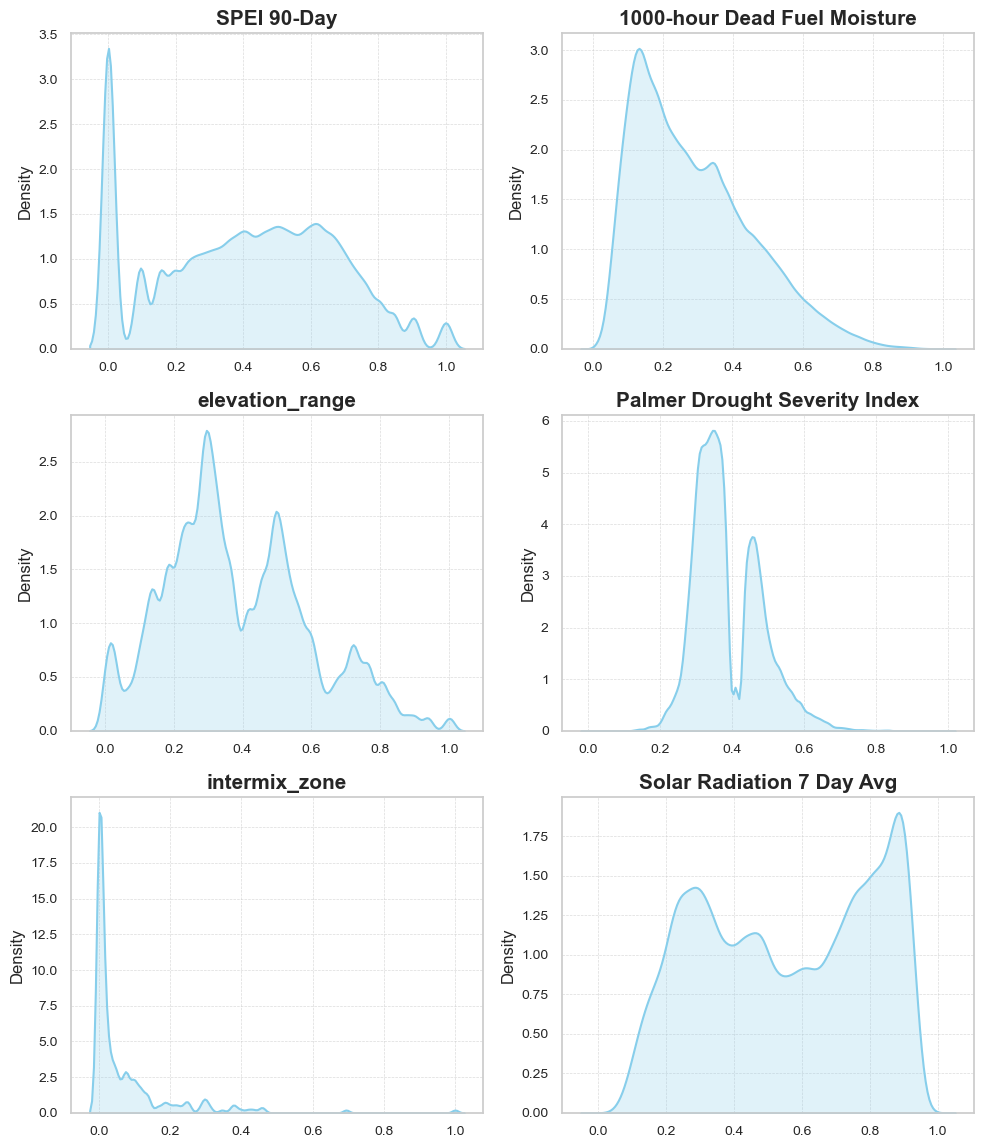

'../plots/features/KDE_{df.columns[0]}.png'

In [49]:
grid_kde(X[damage_xgb_top5])

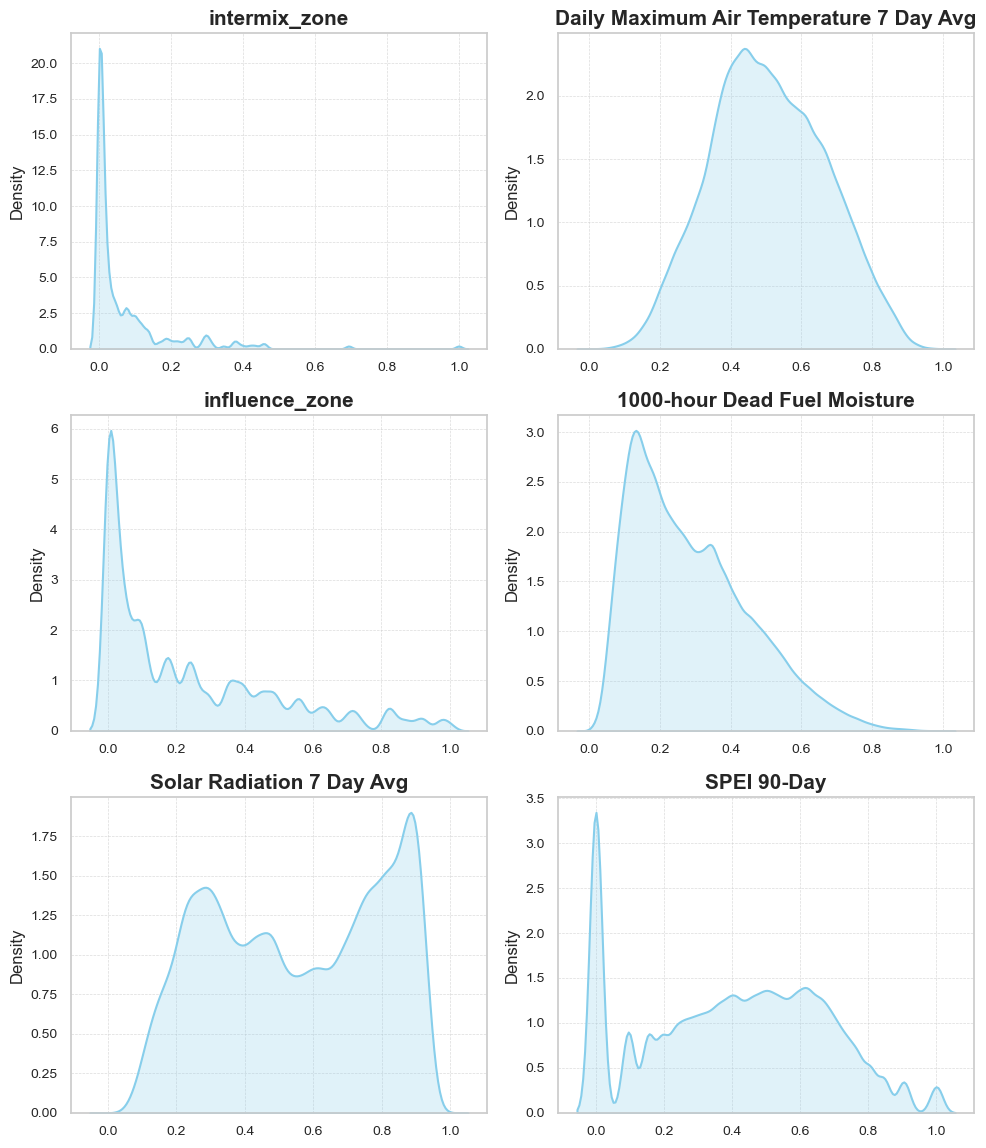

'../plots/features/KDE_{df.columns[0]}.png'

In [50]:
grid_kde(X[damage_rf_top5])